# 08 - Latent preference model (legacy pre-protocol benchmark)

**Archive notice (2026-08-14): this notebook is a legacy benchmark and is not the live Stage 1 pipeline.** Its leave-two-out sample, tie handling, factor artifact, and closing calibration route predate the frozen cycle. Live training, complete-catalogue evaluation, protected splits, exact tie metrics, production refits, and fold-in are implemented by the cycle-scoped source modules and manifests under `outputs/modeling/cycles/s1-v2-20260814`.

Historically, this notebook factorized the user-by-game ownership matrix into latent factors and produced per-user, per-game **preference scores**. Those scores were ownership-derived indices, not dollar valuations. Its saved results remain useful only as a legacy comparison.

The evaluation is built to expose weak performance rather than flatter the model. We use a reproducible per-user split with the usual leakage channels closed:

- a user needs at least three owned games (one validation, one test holdout, the rest training); users below that stay in training but are excluded from ranking evaluation, and the excluded share is reported;
- popularity is computed from the training matrix only;
- factors are fit only after the held-out interactions are removed;
- each user's training positives (and their other holdout) are removed from the candidate list, while the held-out target stays an eligible candidate;
- the validation holdout selects the model and rank `k`; a separate test holdout is used for the final comparison;
- the popularity baseline is reported, not a target. Failing to beat it would be kept and analyzed, not tuned away.

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src import valuation as val

rng = np.random.default_rng(0)

## Build the sparse ownership matrices

We read the user, item, and playtime columns and build the binary preference matrix (and the playtime-weighted confidence matrix, used only by the optional ALS upgrade) via `src/valuation.py`. The full matrix is never densified.

In [2]:
user_items_df = pd.read_csv('../outputs/tables/user_items_df.csv',
                            usecols=['user_id', 'item_id', 'playtime_forever'],
                            dtype={'user_id': str, 'item_id': str})
data = val.build_user_item_matrices(user_items_df)
M = data.preference_matrix.tocsr()
n_users, n_items = M.shape
print('ownership matrix:', M.shape, 
      '\nno. of nonzero entries:', f'{M.nnz:,}',
      '\ndensity', round(M.nnz/(n_users*n_items), 5))

ownership matrix: (70912, 10978) 
no. of nonzero entries: 5,094,082 
density 0.00654


## Reproducible per-user split (leave-two-out)

For every user with at least three owned games we hold out one game for validation and one for test, uniformly at random with a fixed seed. The training matrix removes those entries. Users with fewer than three games remain in training but are not evaluated.

In [3]:
indptr, indices = M.indptr, M.indices
val_item = np.full(n_users, -1)
test_item = np.full(n_users, -1)
rows_tr, cols_tr = [], []
split_rng = np.random.default_rng(42)
for u in range(n_users):
    items_u = indices[indptr[u]:indptr[u + 1]]
    if items_u.size >= 3:
        chosen = split_rng.choice(items_u, size=2, replace=False)
        val_item[u], test_item[u] = chosen[0], chosen[1]
        keep = items_u[(items_u != chosen[0]) & (items_u != chosen[1])]
    else:
        keep = items_u
    rows_tr.append(np.full(keep.size, u))
    cols_tr.append(keep)
rows_tr = np.concatenate(rows_tr); cols_tr = np.concatenate(cols_tr)
M_train = sp.csr_matrix((np.ones(rows_tr.size), (rows_tr, cols_tr)), shape=M.shape)

eval_users_all = np.where(test_item >= 0)[0]
excluded = n_users - eval_users_all.size
print('eligible (evaluable) users:', f'{eval_users_all.size:,}',
      '\nexcluded (<3 games):', f'{excluded:,}',
      f'({excluded / n_users:.1%})')

eligible (evaluable) users: 65,837 
excluded (<3 games): 5,075 (7.2%)


## Metrics and ranking evaluation

For a sampled set of evaluation users we score every game, mask each user's training positives and their other holdout, and read off the rank of the held-out test game. We report Recall@K and NDCG@K (with one held-out positive, hit rate equals Recall@K), plus catalogue coverage and how concentrated the recommendations are on the most popular games. AUC against sampled negatives is reported as a secondary number, since it is inflated when positives are rare among thousands of items.

In [4]:
K = 10
n_eval = min(4000, eval_users_all.size) # too computationally heavy to do all users (65,837)
eval_users = np.sort(rng.choice(eval_users_all, size=n_eval, replace=False))
train_csr = M_train.tocsr()

def evaluate_scores(score_fn, eval_users, K=10, batch=512, n_neg=100, seed=1):
    neg_rng = np.random.default_rng(seed)
    recalls, ndcgs, aucs, topk_items = [], [], [], []
    for start in range(0, eval_users.size, batch):
        bu = eval_users[start:start + batch]
        S = score_fn(bu).astype(float).copy()
        for li, u in enumerate(bu):
            tr = train_csr.indices[train_csr.indptr[u]:train_csr.indptr[u + 1]]
            S[li, tr] = -np.inf
            S[li, val_item[u]] = -np.inf  # mask the other holdout
        for li, u in enumerate(bu):
            t = test_item[u]
            target = S[li, t]
            rank = int(np.sum(S[li] > target))  # 0-based rank of the target
            hit = rank < K
            recalls.append(float(hit))
            ndcgs.append(1.0 / np.log2(rank + 2) if hit else 0.0)
            order = np.argpartition(-S[li], K)[:K]
            topk_items.append(order)
            owned = set(train_csr.indices[train_csr.indptr[u]:train_csr.indptr[u + 1]].tolist())
            owned.add(int(val_item[u]))
            negs = []
            while len(negs) < n_neg:
                c = int(neg_rng.integers(n_items))
                if c not in owned and c != t:
                    negs.append(c)
            aucs.append(float(np.mean(target > S[li, negs])))
    cov = len(set(np.concatenate(topk_items).tolist())) / n_items
    return {'recall': np.mean(recalls), 'ndcg': np.mean(ndcgs),
            'auc': np.mean(aucs), 'coverage': cov,
            'topk': np.concatenate(topk_items)}

## Model selection on the validation holdout

We pick the SVD rank `k` by validation Recall@K, scoring against the *validation* target (masking training positives and the test holdout). This keeps model selection off the test holdout.

In [5]:
def make_svd_scorer(P, Q):
    return lambda bu: P[bu] @ Q.T

def evaluate_validation(P, Q, eval_users, K=10, batch=512):
    recalls = []
    for start in range(0, eval_users.size, batch):
        bu = eval_users[start:start + batch]
        S = (P[bu] @ Q.T).astype(float).copy()
        for li, u in enumerate(bu):
            tr = train_csr.indices[train_csr.indptr[u]:train_csr.indptr[u + 1]]
            S[li, tr] = -np.inf
            S[li, test_item[u]] = -np.inf  # mask the test target during validation
        for li, u in enumerate(bu):
            v = val_item[u]
            rank = int(np.sum(S[li] > S[li, v]))
            recalls.append(float(rank < K))
    return float(np.mean(recalls))

val_users = eval_users  # same sampled users, scored against their validation target
svd_factors = {}
for k in [16, 32, 64]:
    P, Q = val.fit_svd(M_train, k=k)
    svd_factors[k] = (P, Q)
    vr = evaluate_validation(P, Q, val_users, K=K)
    print(f'SVD k={k:>2}  validation Recall@{K} = {vr:.4f}')
best_k = max(svd_factors, key=lambda k: evaluate_validation(*svd_factors[k], val_users, K=K))
print('selected k =', best_k)

SVD k=16  validation Recall@10 = 0.3140
SVD k=32  validation Recall@10 = 0.3392
SVD k=64  validation Recall@10 = 0.3192
selected k = 32


## Test comparison: SVD vs NMF vs popularity baseline

Final numbers on the held-out test target. The popularity baseline scores every game by its training ownership count (the same ordering for all users, but each user's own training games are still masked).

In [6]:
P_svd, Q_svd = svd_factors[best_k]
P_nmf, Q_nmf = val.fit_nmf(M_train, k=best_k, max_iter=120)

pop = np.asarray(M_train.sum(axis=0)).ravel()  # training popularity
def pop_scorer(bu):
    return np.tile(pop, (bu.size, 1))

results = {
    'popularity': evaluate_scores(pop_scorer, eval_users, K=K),
    f'SVD (k={best_k})': evaluate_scores(make_svd_scorer(P_svd, Q_svd), eval_users, K=K),
    f'NMF (k={best_k})': evaluate_scores(make_svd_scorer(P_nmf, Q_nmf), eval_users, K=K),
}
print(f"{'model':>14} {'Recall@%d'%K:>9} {'NDCG@%d'%K:>8} {'AUC':>6} {'coverage':>9}")
for name, r in results.items():
    print(f"{name:>14} {r['recall']:>9.4f} {r['ndcg']:>8.4f} {r['auc']:>6.3f} {r['coverage']:>9.4f}")

sklearn.decomposition._nmf: ConvergenceWarning: Maximum number of iterations 120 reached. Increase it to improve convergence.
  warnings.warn(


         model Recall@10  NDCG@10    AUC  coverage
    popularity    0.1945   0.1227  0.962    0.0073
    SVD (k=32)    0.3387   0.2309  0.931    0.0511
    NMF (k=32)    0.3260   0.2188  0.968    0.0524


## Where the model helps: performance by user library size, and popularity concentration

Recall@K split by the user's training library size (deciles) shows where the latent model beats popularity. We also report how concentrated each method's top-K recommendations are on the most popular 1% of games.

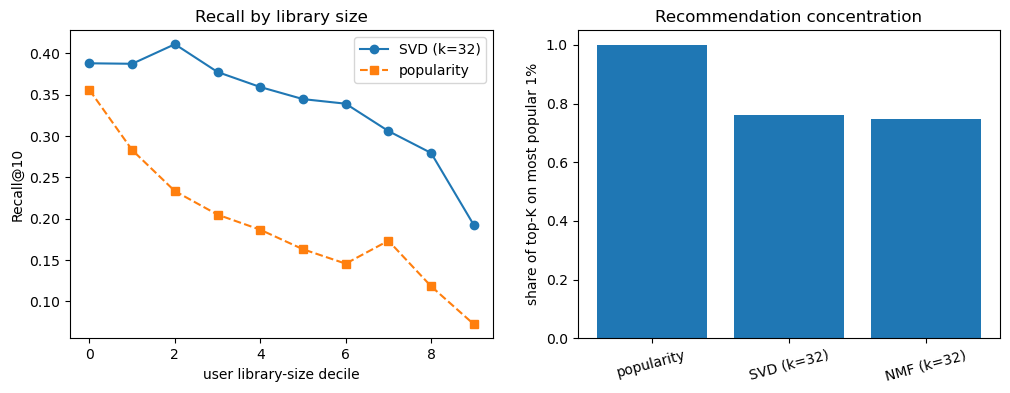

In [7]:
lib_size = np.diff(train_csr.indptr)[eval_users]
deciles = pd.qcut(lib_size, 10, labels=False, duplicates='drop')

def recall_per_user(score_fn, eval_users, K=10, batch=512):
    out = []
    for start in range(0, eval_users.size, batch):
        bu = eval_users[start:start + batch]
        S = score_fn(bu).astype(float).copy()
        for li, u in enumerate(bu):
            tr = train_csr.indices[train_csr.indptr[u]:train_csr.indptr[u + 1]]
            S[li, tr] = -np.inf; S[li, val_item[u]] = -np.inf
        for li, u in enumerate(bu):
            out.append(float(np.sum(S[li] > S[li, test_item[u]]) < K))
    return np.array(out)

r_svd = recall_per_user(make_svd_scorer(P_svd, Q_svd), eval_users, K=K)
r_pop = recall_per_user(pop_scorer, eval_users, K=K)
by_dec = pd.DataFrame({'decile': deciles, 'svd': r_svd, 'pop': r_pop}).groupby('decile').mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(by_dec.index, by_dec['svd'], 'o-', label=f'SVD (k={best_k})')
ax[0].plot(by_dec.index, by_dec['pop'], 's--', label='popularity')
ax[0].set_xlabel('user library-size decile'); ax[0].set_ylabel(f'Recall@{K}')
ax[0].set_title('Recall by library size'); ax[0].legend()

top1pct = set(np.argsort(-pop)[:max(1, n_items // 100)].tolist())
conc = {name: np.mean([i in top1pct for i in r['topk']]) for name, r in results.items()}
ax[1].bar(range(len(conc)), list(conc.values()))
ax[1].set_xticks(range(len(conc))); ax[1].set_xticklabels(list(conc.keys()), rotation=15)
ax[1].set_ylabel('share of top-K on most popular 1%')
ax[1].set_title('Recommendation concentration')
plt.savefig('../outputs/figures/08_valuation_eval.png'); plt.show()

## Internal concordance with the notebook 03 ownership proxy

As a face-validity check we ask whether bundles whose games have higher mean preference score also have more owners (`users_own_all`) on the full-coverage bundles. This is **internal concordance**, not independent validation: both the preference score and `users_own_all` are functions of the same ownership matrix, so agreement is reassuring but cannot establish construct validity. The per-game mean preference score is the average over users of the reconstructed score, which equals `mean_u P[u] . Q[g]`.

In [8]:
from scipy.stats import spearmanr
P, Q = P_svd, Q_svd
per_game_score = Q @ P.mean(axis=0)  # mean over users of the reconstructed score
score_by_item = pd.Series(per_game_score, index=data.item_ids)

bundle_items_df = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                              dtype={'bundle_id': str, 'item_id': str}).dropna(subset=['item_id'])
proxy = pd.read_csv('../outputs/tables/bundle_demand_proxy.csv', dtype={'bundle_id': str})
full_cov = proxy[proxy['panel_coverage'] == 1.0][['bundle_id', 'users_own_all']]

bi = bundle_items_df.copy()
bi['game_score'] = bi['item_id'].map(score_by_item)
bundle_score = bi.groupby('bundle_id')['game_score'].mean().rename('mean_pref_score')
merged = full_cov.merge(bundle_score, on='bundle_id').dropna()
rho, pval = spearmanr(merged['mean_pref_score'], merged['users_own_all'])
print(f'full-coverage bundles compared: {len(merged)}')
print(f'Spearman(mean preference score, users_own_all) = {rho:.3f}  (p = {pval:.1e})')
print('Internal concordance only: both derive from the same ownership matrix.')

full-coverage bundles compared: 238
Spearman(mean preference score, users_own_all) = 0.713  (p = 2.8e-38)
Internal concordance only: both derive from the same ownership matrix.


In [9]:
np.savez('../outputs/tables/preference_factors.npz',
         P=P_svd.astype(np.float32), Q=Q_svd.astype(np.float32),
         user_ids=data.user_ids, item_ids=data.item_ids, k=best_k)

## Notes

- The latent model is compared against a popularity baseline reported as-is; the split, metrics, and negative sampling are seeded and reproducible.
- The outputs are latent preference scores, not valuations. The attempted dollar anchor and CMM route were later rejected and archived. The live replacement uses four explicit pseudo-utility scenarios and a fixed-bundle SBA design; this notebook supplies no live downstream artifact.
- Caveats from the data stage still hold: the panel is Australian, ownership is not purchase, and the snapshot prices are a single cross-section. The preference model reduces but does not remove these (see notes/assumptions_and_limitations.md).